In [1]:
import sys
import os

# Adds the parent directory to the system path so we can import from 'src'
sys.path.append(os.path.abspath(os.path.join('..')))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from src.models import perform_kpss_test, fit_arma_model
from src.diagnostics import run_residual_diagnostics
from src.ts_utils import acf1, ccf

# Generate Syntactic ARMA(p,q) Time Series Data

Generate a time series with a length of 10,000 observations from the model:

$X_t = 0.3 X_{t-1} - 0.4 X_{t-2} + 0.4 W_{t-1} - 0.1 W_{t-2} + W_t$

In [27]:
# Generate the ARMA(2,2) model X_t = 0.3 X_{t-1} - 0.4 X_{t-2} + 0.4 W_{t-1} - 0.1 W_{t-2} + W_t

n = 10000 # sample size
phi = [1, -0.3, 0.4]
theta = [1, 0.4, -0.1]
sd = 2.0

arma_ts = sm.tsa.arma_generate_sample(ar = phi, ma = theta, nsample = n, scale = sd)
arma_ts = pd.Series(arma_ts, index = range(n))

# KPSS Test for Stationarity

In [28]:
pip install arch

In [29]:
from arch.unitroot import KPSS

# Perform KPSS test
kpss_test = KPSS(arma_ts)
p_value = kpss_test.pvalue

# Print the results
print(f'KPSS test p-value: {p_value:.3f}\n')

# Interpret the results
alpha = 0.05
if p_value >= alpha:
     print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else:
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')

KPSS test p-value: 0.193

The time series is stationary (fail to reject "H0: The time series is stationary" at a 5% significance level).


/tmp/ipython-input-2473822595.py:4: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss_test = KPSS(arma_ts)


# Plot time series, ACF and PACF

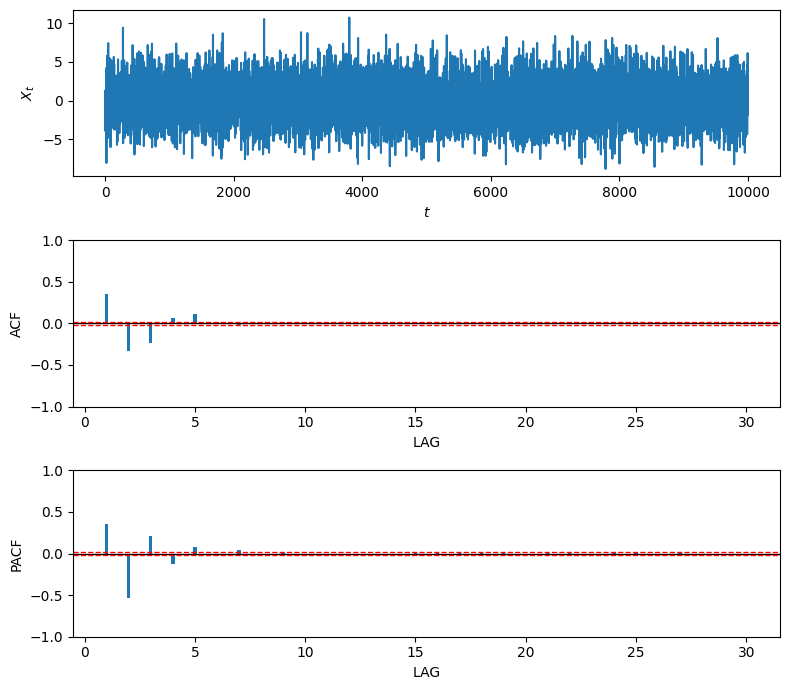

In [30]:
# Plot time series
fig, axes = plt.subplots(nrows = 3, figsize = (8,7))

arma_ts.plot(ax = axes[0])
axes[0].set_xlabel('$t$')
axes[0].set_ylabel('$X_t$')

# plot ACF
acf1(arma_ts, nlags = 30, ax = axes[1], width = 0.15)
axes[1].set_ylim(-1, 1)

# plot PACF
acf1(arma_ts, nlags = 30, ax = axes[2], width = 0.15, pacf = True)
axes[2].set_ylim(-1, 1)

fig.tight_layout()
plt.show()


**Based on ACF and PACF plots I choose p=5 and q=5**

# Fit an ARMA(5,5) Model

In [31]:
# Fit an ARMA(5,5) model

model = sm.tsa.arima.ARIMA(arma_ts, order=(5, 0, 5))
result = model.fit()
print(result.summary())


                               SARIMAX Results                                
Dep. Variable:                   None   No. Observations:                10000
Model:                 ARIMA(5, 0, 5)   Log Likelihood              -21090.804
Date:                Wed, 17 Dec 2025   AIC                          42205.608
Time:                        12:13:18   BIC                          42292.132
Sample:                             0   HQIC                         42234.896
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0024      0.025     -0.096      0.923      -0.050       0.046
ar.L1          0.6527      0.541      1.207      0.227      -0.407       1.713
ar.L2         -0.7394      0.698     -1.060      0.2

**Max p-value is ma.L2=0.986 ===> Reduce q from 5 to 4 ===> New model is ARMA(5,4)**

# Fit an ARMA(5,4) Model

In [32]:
# Fit an ARMA(5,4) model

model = sm.tsa.arima.ARIMA(arma_ts, order=(5, 0, 4))
result = model.fit()
print(result.summary())


                               SARIMAX Results                                
Dep. Variable:                   None   No. Observations:                10000
Model:                 ARIMA(5, 0, 4)   Log Likelihood              -21091.040
Date:                Wed, 17 Dec 2025   AIC                          42204.079
Time:                        12:14:08   BIC                          42283.393
Sample:                             0   HQIC                         42230.926
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0023      0.025     -0.095      0.924      -0.050       0.046
ar.L1          0.6782      0.559      1.214      0.225      -0.417       1.773
ar.L2         -0.1978      0.658     -0.301      0.7

**Max p-value is ma.L1=0.973 ===> Reduce q from 4 to 3 ===> New model is ARMA(5,3)**

# Fit an ARMA(5,3) Model

In [33]:
# Fit an ARMA(5,3) model

model = sm.tsa.arima.ARIMA(arma_ts, order=(5, 0, 3))
result = model.fit()
print(result.summary())


                               SARIMAX Results                                
Dep. Variable:                   None   No. Observations:                10000
Model:                 ARIMA(5, 0, 3)   Log Likelihood              -21092.658
Date:                Wed, 17 Dec 2025   AIC                          42205.316
Time:                        12:14:24   BIC                          42277.420
Sample:                             0   HQIC                         42229.723
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0022      0.024     -0.092      0.927      -0.050       0.045
ar.L1          1.2983      2.336      0.556      0.578      -3.281       5.877
ar.L2         -0.6844      2.560     -0.267      0.7

**Max p-value is ar.L4=0.984 ===> Reduce p from 5 to 4 ===> New model is ARMA(4,3)**

# Fit an ARMA(4,3) Model

In [36]:
# Fit an ARMA(4,3) model

model = sm.tsa.arima.ARIMA(arma_ts, order=(4, 0, 3))
result = model.fit()
print(result.summary())


                               SARIMAX Results                                
Dep. Variable:                   None   No. Observations:                10000
Model:                 ARIMA(4, 0, 3)   Log Likelihood              -21092.481
Date:                Wed, 17 Dec 2025   AIC                          42202.961
Time:                        12:17:50   BIC                          42267.854
Sample:                             0   HQIC                         42224.927
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0026      0.025     -0.102      0.919      -0.052       0.047
ar.L1          1.2498      0.244      5.125      0.000       0.772       1.728
ar.L2         -0.6587      0.288     -2.288      0.0

**Max p-value is ar.L4=0.937 ===> Reduce p from 4 to 3 ===> New model is ARMA(3,3)**

# Fit an ARMA(3,3) Model

In [37]:
# Fit an ARMA(3,3) model

model = sm.tsa.arima.ARIMA(arma_ts, order=(3, 0, 3))
result = model.fit()
print(result.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                   None   No. Observations:                10000
Model:                 ARIMA(3, 0, 3)   Log Likelihood              -21092.661
Date:                Wed, 17 Dec 2025   AIC                          42201.323
Time:                        12:19:46   BIC                          42259.006
Sample:                             0   HQIC                         42220.848
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0024      0.024     -0.099      0.921      -0.049       0.045
ar.L1          0.3892      2.476      0.157      0.875      -4.464       5.242
ar.L2         -0.4211      0.743     -0.567      0.5

**Max p-value is ar.L3=0.974 ===> Reduce p from 3 to 2 ===> New model is ARMA(2,3)**

# Fit an ARMA(2,3) Model

In [38]:
# Fit an ARMA(2,3) model

model = sm.tsa.arima.ARIMA(arma_ts, order=(2, 0, 3))
result = model.fit()
print(result.summary())


                               SARIMAX Results                                
Dep. Variable:                   None   No. Observations:                10000
Model:                 ARIMA(2, 0, 3)   Log Likelihood              -21092.669
Date:                Wed, 17 Dec 2025   AIC                          42199.338
Time:                        12:22:11   BIC                          42249.810
Sample:                             0   HQIC                         42216.422
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0024      0.024     -0.099      0.921      -0.049       0.045
ar.L1          0.3077      0.031      9.837      0.000       0.246       0.369
ar.L2         -0.3963      0.029    -13.546      0.0

Max p-value is ma.L3=0.697 ===> Reduce q from 3 to 2 ===> New model is ARMA(2,2)

# Fit an ARMA(2,2) Model

In [39]:
# Fit an ARMA(2,2) model

model = sm.tsa.arima.ARIMA(arma_ts, order=(2, 0, 2))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                   None   No. Observations:                10000
Model:                 ARIMA(2, 0, 2)   Log Likelihood              -21092.752
Date:                Wed, 17 Dec 2025   AIC                          42197.505
Time:                        12:23:47   BIC                          42240.767
Sample:                             0   HQIC                         42212.148
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0024      0.024     -0.100      0.921      -0.049       0.044
ar.L1          0.3003      0.026     11.412      0.000       0.249       0.352
ar.L2         -0.3861      0.012    -31.199      0.0

**All p-values for AR and MA coefficients are significant so now I check the  const p-value. It is 0.921 then I remove it from the model.**

# Fit an ARMA(2,2) Model with no Intercept

In [40]:
# Fit an ARMA(2,2) model: refining with no intercept

model = sm.tsa.arima.ARIMA(arma_ts, order=(2, 0, 2), trend = 'n')
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                   None   No. Observations:                10000
Model:                 ARIMA(2, 0, 2)   Log Likelihood              -21092.757
Date:                Wed, 17 Dec 2025   AIC                          42195.514
Time:                        12:30:17   BIC                          42231.566
Sample:                             0   HQIC                         42207.718
                              - 10000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3003      0.026     11.418      0.000       0.249       0.352
ar.L2         -0.3861      0.012    -31.199      0.000      -0.410      -0.362
ma.L1          0.3973      0.028     14.217      0.0

# Checking final model

**Input model**: $X_t = 0.3 X_{t-1} - 0.4 X_{t-2} + 0.4 W_{t-1} - 0.1 W_{t-2} + W_t$

**Fitted model**: $X_t = 0.3 X_{t-1} - 0.39 X_{t-2} + 0.4 W_{t-1} - 0.1 W_{t-2} + W_t$